### Análise Exploratória dos Dados

Esse notebook tem por objetivo fazer a análise exploratória dos dados da base organizada da PNAD Contínua para os anos de 2019-2025.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

#### Carregamento da base

In [100]:
df = pd.read_csv("../data/PNAD_empilhada.csv")

df.head()

,Ano,Trimestre,UF,V1028,V2007,V2009,V2010,V3009A,V3014,V4001,V4010,V4012,V4013,V4028,V4029,V403312,V4039,V4040,V4071
0,2019,1,26,259.050135,1,35,4,7.0,1.0,1.0,8153.0,6.0,14001.0,NaN,NaN,2000.0,44.0,3.0,NaN
1,2019,1,26,259.050135,2,31,1,12.0,1.0,1.0,8153.0,6.0,14001.0,NaN,NaN,2000.0,44.0,3.0,NaN
2,2019,1,26,259.050135,1,10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,26,287.125126,1,57,4,5.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
4,2019,1,26,287.125126,2,22,4,7.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [101]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 530602 entries, 0 to 530601
Data columns (total 19 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Ano        530602 non-null  int64  
 1   Trimestre  530602 non-null  int64  
 2   UF         530602 non-null  int64  
 3   V1028      530602 non-null  float64
 4   V2007      530602 non-null  int64  
 5   V2009      530602 non-null  int64  
 6   V2010      530602 non-null  int64  
 7   V3009A     339465 non-null  float64
 8   V3014      328497 non-null  float64
 9   V4001      432064 non-null  float64
 10  V4010      184914 non-null  float64
 11  V4012      184914 non-null  float64
 12  V4013      184914 non-null  float64
 13  V4028      16357 non-null   float64
 14  V4029      102753 non-null  float64
 15  V403312    177983 non-null  float64
 16  V4039      184914 non-null  float64
 17  V4040      184914 non-null  float64
 18  V4071      247150 non-null  float64
dtypes: float64(13), int64(6)
memory us

,Ano,Trimestre,UF,V1028,V2007,V2009,V2010,V3009A,V3014,V4001,V4010,V4012,V4013,V4028,V4029,V403312,V4039,V4040,V4071
count,530602.000000,530602.000000,530602.0,530602.000000,530602.000000,530602.000000,530602.000000,339465.000000,328497.000000,432064.000000,184914.000000,184914.000000,184914.000000,16357.000000,102753.000000,177983.000000,184914.000000,184914.000000,247150.000000
mean,2022.003025,2.501027,26.0,497.434156,1.525226,36.361644,2.899222,8.637300,1.445730,1.624512,5984.161691,4.080756,51616.873017,1.204255,1.467266,1878.445537,37.795435,3.446862,1.873097
std,2.039581,1.120755,0.0,367.955703,0.499364,22.046121,1.394460,2.365201,0.497047,0.484249,2348.884010,1.577956,31503.450397,0.403169,0.498930,3138.826061,12.489779,0.903619,0.332865
min,2019.000000,1.000000,26.0,13.668183,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000
25%,2020.000000,1.000000,26.0,267.813601,1.000000,18.000000,1.000000,7.000000,1.000000,1.000000,4229.000000,3.000000,31000.000000,1.000000,1.000000,700.000000,30.000000,3.000000,2.000000
50%,2022.000000,3.000000,26.0,441.642067,2.000000,35.000000,4.000000,10.000000,1.000000,2.000000,6111.000000,3.000000,48080.000000,1.000000,1.000000,1212.000000,40.000000,4.000000,2.000000
75%,2024.000000,4.000000,26.0,638.035340,2.000000,53.000000,4.000000,10.000000,2.000000,2.000000,8182.000000,6.000000,84013.000000,1.000000,2.000000,1900.000000,44.000000,4.000000,2.000000
max,2025.000000,4.000000,26.0,33788.162620,2.000000,113.000000,9.000000,15.000000,2.000000,2.000000,9629.000000,7.000000,99000.000000,2.000000,2.000000,200000.000000,120.000000,4.000000,2.000000


Esses primeiros dados nos mostram uma visualização da "cara" da base, verificando quais tipos tem cada variável, quantos registros totais temos, e algumas estatísticas descritivas para cada variável. 

#### Valores ausentes

In [102]:
df.isnull().sum().sort_values(ascending=False)

V4028        514245
V4029        427849
V403312      352619
V4013        345688
V4040        345688
V4039        345688
V4010        345688
V4012        345688
V4071        283452
V3014        202105
V3009A       191137
V4001         98538
UF                0
Ano               0
Trimestre         0
V1028             0
V2007             0
V2009             0
V2010             0
dtype: int64

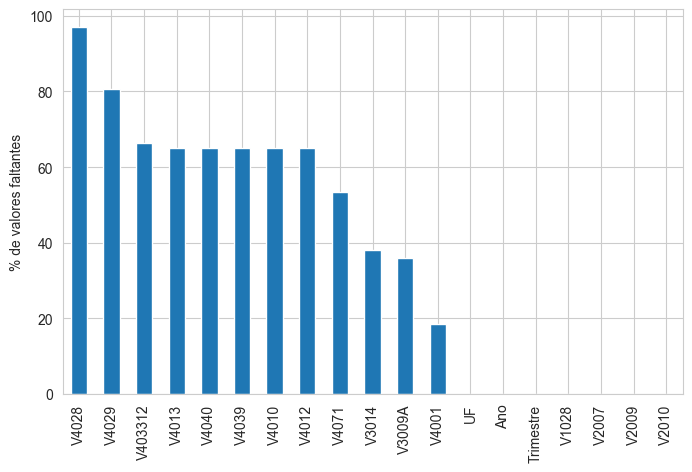

In [103]:
(df.isnull().mean()*100).sort_values(ascending=False).plot.bar()
plt.ylabel("% de valores faltantes")
plt.show()

Aqui observamos quantos valores ausentes tempos por variável. Lembrando que esses valores são representados pela expressão "NaN", e correspondem a valores fora do mapeado pelo dicionário de variáveis, disponibilizado pelo próprio IBGE.

#### Renomeando colunas

In [104]:
df = df.rename(columns={
    "V1028": "peso",
    "V2007": "sexo",
    "V2009": "idade",
    "V2010": "cor_raca",
    "V3009A": "nivel_educacional",
    "V3014": "curso_concluido",
    "V4001": "trabalhou",
    "V4010": "cargo",
    "V4012": "tipo_trabalho",
    "V4013": "atividade",
    "V4028": "servidor_publico",
    "V4029": "carteira_assinada",
    "V403312": "renda",
    "V4039": "horas_semana",
    "V4040": "tempo_trabalho",
    "V4071": "procurou_emprego"
})

#### Tratamento de Valores Não Aplicáveis

Durante a inspeção da base de dados, observou-se a presença de diversos valores ausentes (NaN) em algumas variáveis. No entanto, esses valores não representam dados faltantes decorrentes de erros de coleta ou inconsistências, mas sim situações em que a pergunta correspondente não se aplicava ao indivíduo entrevistado.

Para preservar essa informação e evitar a perda de registros nas análises subsequentes, os valores NaN foram substituídos por um código específico, posteriormente associado à categoria "Não aplicável". Essa abordagem permite manter a consistência da base e garantir que todas as observações sejam consideradas nas análises exploratórias e estatísticas.

As variáveis de renda e horas_semanas não receberão o tratamento, pois seus valores correspondem a valores numéricos, e não categóricos. Sendo assim, permanecerão com NaN.

In [105]:
colunas = [
    "nivel_educacional",
    "curso_concluido",
    "trabalhou",
    "cargo",
    "tipo_trabalho",
    "atividade",
    "servidor_publico",
    "carteira_assinada",
    "tempo_trabalho",
    "procurou_emprego"
]

df[colunas] = df[colunas].fillna(999)

In [106]:
df.isnull().sum().sort_values(ascending=False)

renda                352619
horas_semana         345688
Ano                       0
UF                        0
Trimestre                 0
peso                      0
sexo                      0
nivel_educacional         0
curso_concluido           0
idade                     0
cor_raca                  0
cargo                     0
trabalhou                 0
tipo_trabalho             0
atividade                 0
carteira_assinada         0
servidor_publico          0
tempo_trabalho            0
procurou_emprego          0
dtype: int64

#### Correlação entre variáveis numéricas

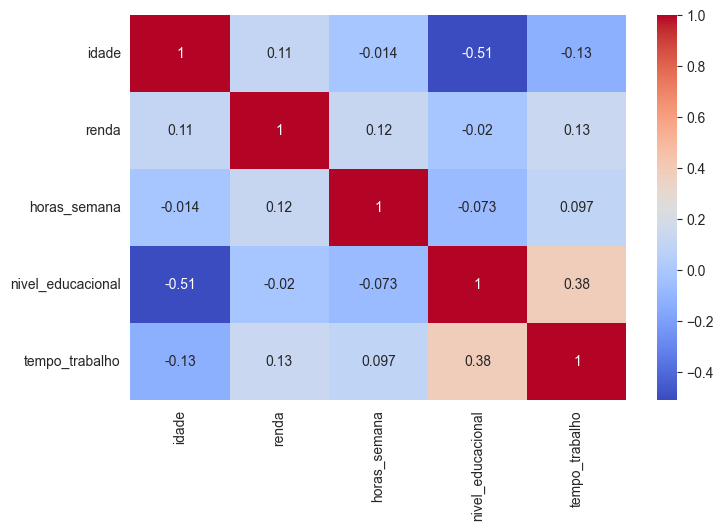

In [107]:
variaveis = [
    "idade",
    "renda",
    "horas_semana",
    "nivel_educacional",
    "tempo_trabalho"
]

corr = df[variaveis].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

#### Distribuição por sexo

In [108]:
df["sexo"] = df["sexo"].map({
    1: "Homem",
    2: "Mulher",
    999: "Não Aplicável"
})

In [109]:
df["sexo"].value_counts(dropna=False)

sexo
Mulher    278686
Homem     251916
Name: count, dtype: int64

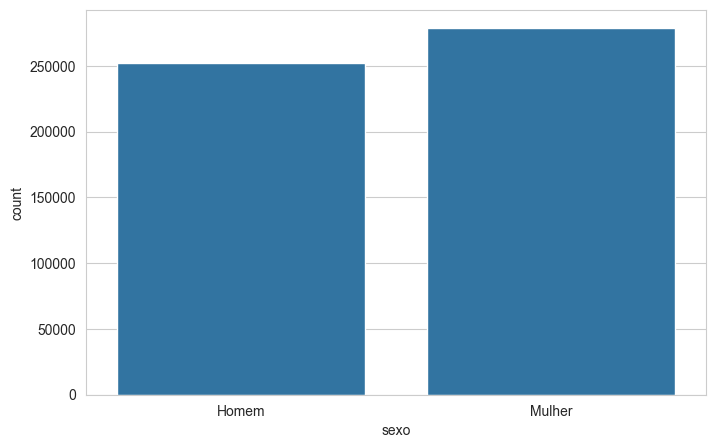

In [110]:
sns.countplot(data=df, x="sexo")
plt.show()

#### Distribuição por idade

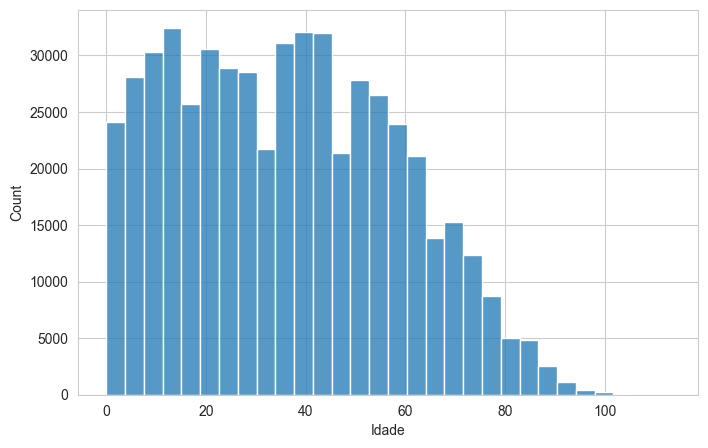

In [111]:
sns.histplot(df["idade"], bins=30)
plt.xlabel("Idade")
plt.show()

In [112]:
df["idade"].describe()

count    530602.000000
mean         36.361644
std          22.046121
min           0.000000
25%          18.000000
50%          35.000000
75%          53.000000
max         113.000000
Name: idade, dtype: float64

#### Cor ou raça

In [113]:
df["cor_raca"] = df["cor_raca"].map({
    1: "Branca",
    2: "Preta",
    3: "Amarela",
    4: "Parda",
    5: "Indígena",
    9: "Ignorado"
})

In [114]:
df["cor_raca"].value_counts(dropna=False)

cor_raca
Parda       316789
Branca      166498
Preta        42552
Indígena      2487
Amarela       2224
Ignorado        52
Name: count, dtype: int64

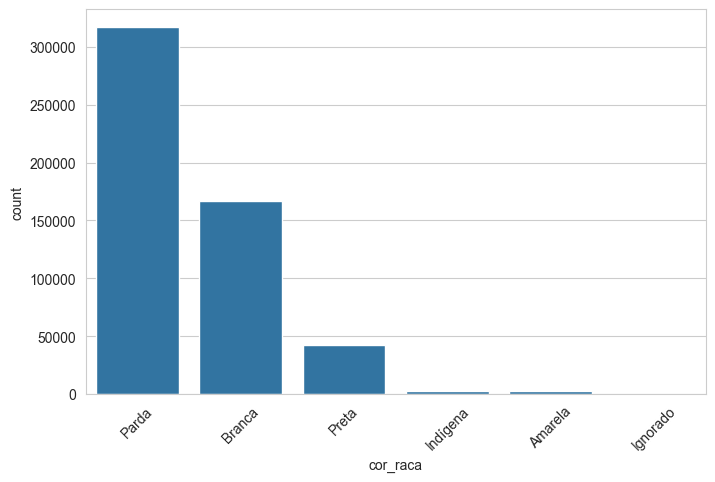

In [115]:
sns.countplot(
    data=df,
    x="cor_raca"
)
plt.xticks(rotation=45)
plt.show()

#### Escolaridade

In [116]:
mapa_escolaridade = {
    1: "Creche",
    2: "Pré-escola",
    3: "Classe de alfabetização (CA)",
    4: "Alfabetização de jovens e adultos",
    5: "Antigo primário (elementar)",
    6: "Antigo ginásio (médio 1º ciclo)",
    7: "Ensino fundamental regular",
    8: "EJA ou supletivo do 1º grau",
    9: "Antigo científico, clássico etc. (médio 2º ciclo)",
    10: "Ensino médio regular",
    11: "EJA ou supletivo do 2º grau",
    12: "Superior - graduação",
    13: "Especialização",
    14: "Mestrado",
    15: "Doutorado",
    999: "Não Aplicável"
}

df["nivel_educacional"] = df["nivel_educacional"].map(mapa_escolaridade)

In [117]:
df["nivel_educacional"].value_counts(dropna=False)

nivel_educacional
Não Aplicável                                        191137
Ensino médio regular                                 127351
Ensino fundamental regular                           116177
Superior - graduação                                  35028
Antigo primário (elementar)                           27285
Especialização                                         9833
Classe de alfabetização (CA)                           7490
EJA ou supletivo do 2º grau                            3359
Antigo científico, clássico etc. (médio 2º ciclo)      3121
Antigo ginásio (médio 1º ciclo)                        3112
EJA ou supletivo do 1º grau                            2769
Mestrado                                               1263
Alfabetização de jovens e adultos                      1136
Pré-escola                                              979
Doutorado                                               546
Creche                                                   16
Name: count, dtype: in

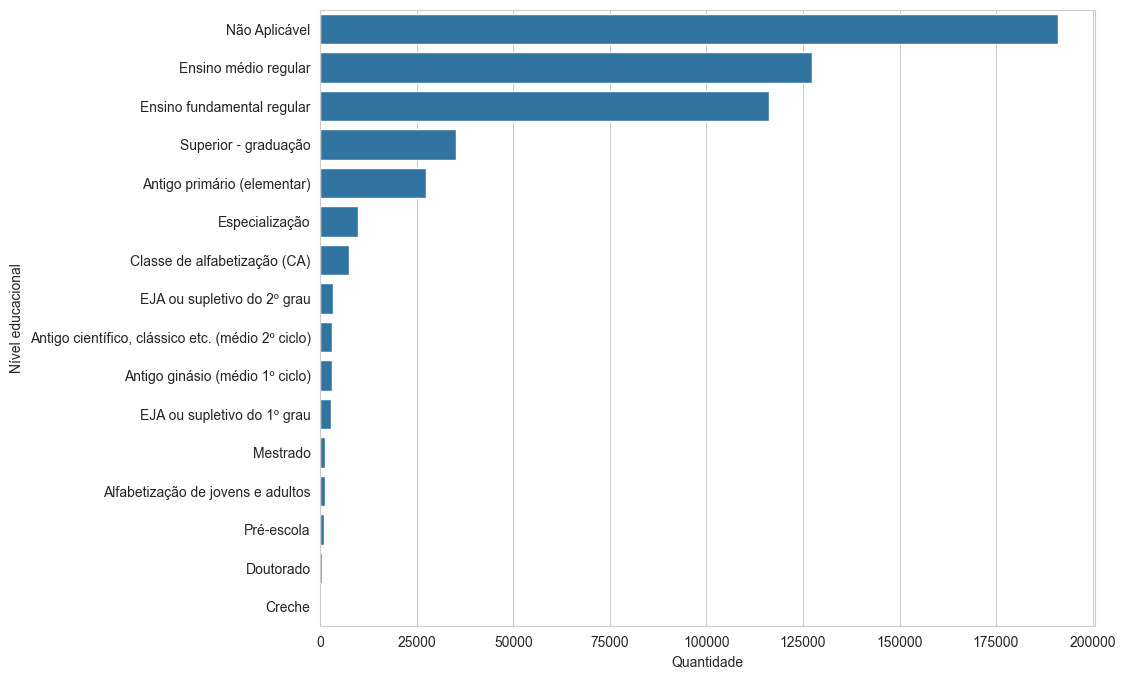

In [118]:
plt.figure(figsize=(10,8))

sns.countplot(
    data=df,
    y="nivel_educacional",
    order=df["nivel_educacional"].value_counts(dropna=False).index
)

plt.xlabel("Quantidade")
plt.ylabel("Nível educacional")
plt.show()

#### Pessoas que trabalham

In [119]:
df["trabalhou"] = df["trabalhou"].map({
    1: "Sim",
    2: "Não",
    999: "Não Aplicável"
})

In [120]:
df["trabalhou"].value_counts(dropna=False)

trabalhou
Não              269829
Sim              162235
Não Aplicável     98538
Name: count, dtype: int64

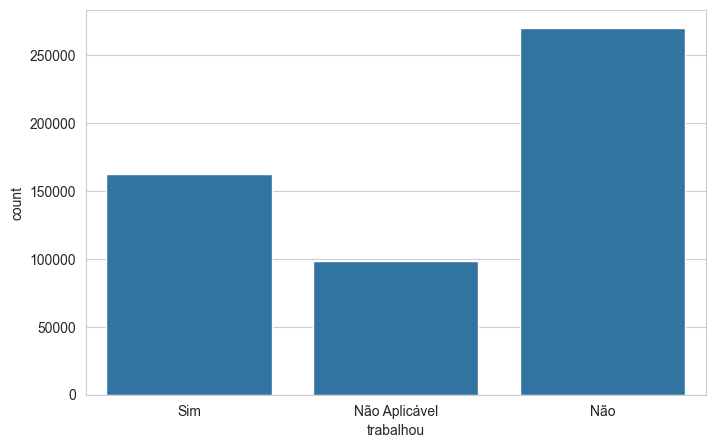

In [121]:
sns.countplot(data=df, x="trabalhou")
plt.show()

#### Tipo de ocupação

In [122]:
mapa_trabalho = {
    1: "Trabalhador doméstico",
    2: "Militar",
    3: "CLT",
    4: "Concursado",
    5: "Empregador",
    6: "Conta própria",
    7: "Familiar não remunerado",
    999: "Não Aplicável"
}

df["tipo_trabalho"] = df["tipo_trabalho"].map(mapa_trabalho)

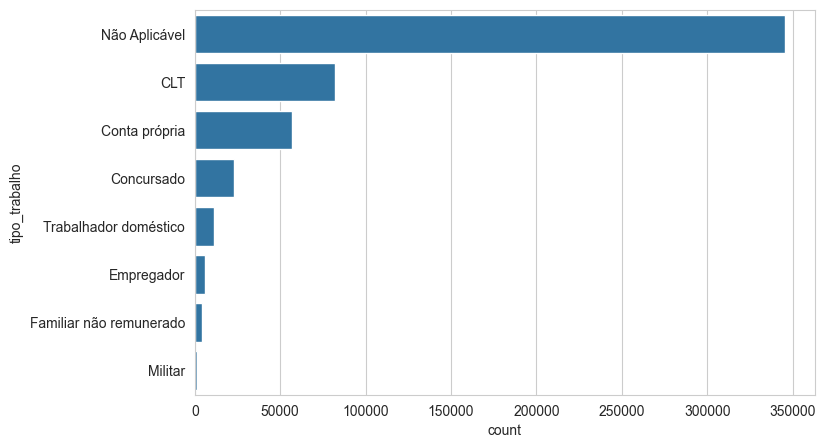

In [123]:
sns.countplot(
    data=df,
    y="tipo_trabalho",
    order=df["tipo_trabalho"].value_counts(dropna=False).index
)
plt.show()

#### Distribuição da renda

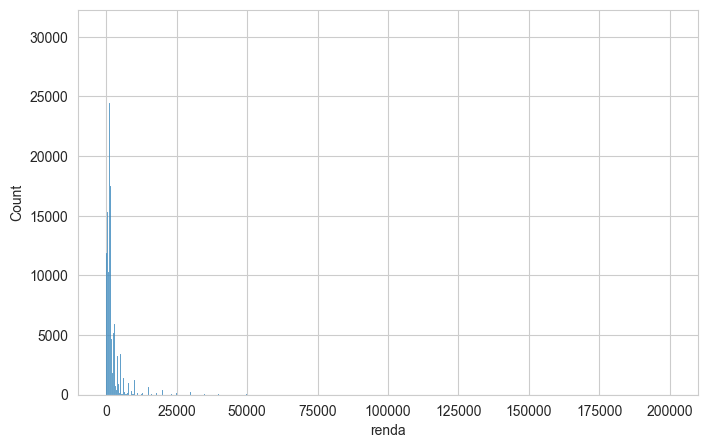

In [125]:
sns.histplot(data=df, x="renda")
plt.show()

In [126]:
df["renda"].describe()

count    177983.000000
mean       1878.445537
std        3138.826061
min           4.000000
25%         700.000000
50%        1212.000000
75%        1900.000000
max      200000.000000
Name: renda, dtype: float64

#### Renda por escolaridade

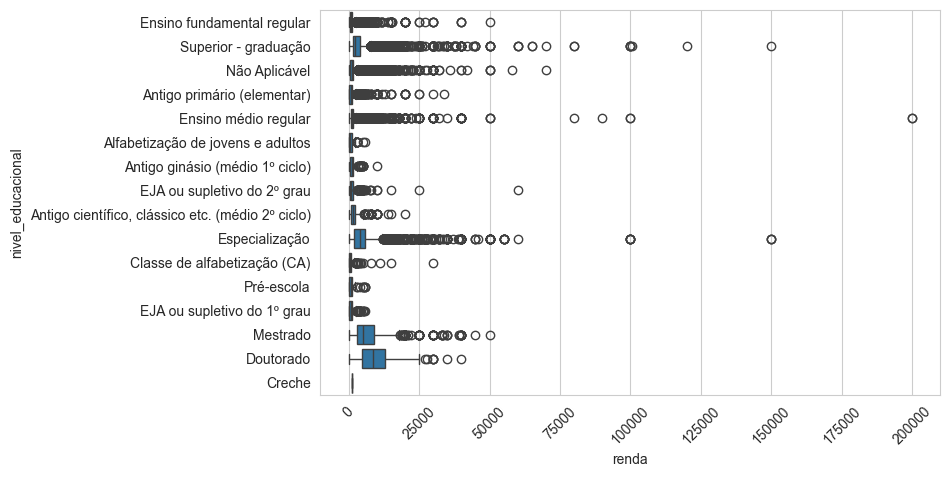

In [127]:
sns.boxplot(
    data=df,
    y="nivel_educacional",
    x="renda"
)

plt.xticks(rotation=45)
plt.show()

#### Renda média por escolaridade

In [128]:
df.groupby("nivel_educacional")["renda"].mean().sort_values()

nivel_educacional
Classe de alfabetização (CA)                          731.682362
Alfabetização de jovens e adultos                     783.746269
EJA ou supletivo do 1º grau                           900.041958
Pré-escola                                            970.140541
Antigo primário (elementar)                          1006.522007
Ensino fundamental regular                           1045.744995
EJA ou supletivo do 2º grau                          1197.646594
Antigo ginásio (médio 1º ciclo)                      1228.010183
Creche                                               1302.000000
Ensino médio regular                                 1499.610319
Não Aplicável                                        1680.155464
Antigo científico, clássico etc. (médio 2º ciclo)    2027.320088
Superior - graduação                                 3541.257948
Especialização                                       5864.812916
Mestrado                                             7409.314314
Doutora

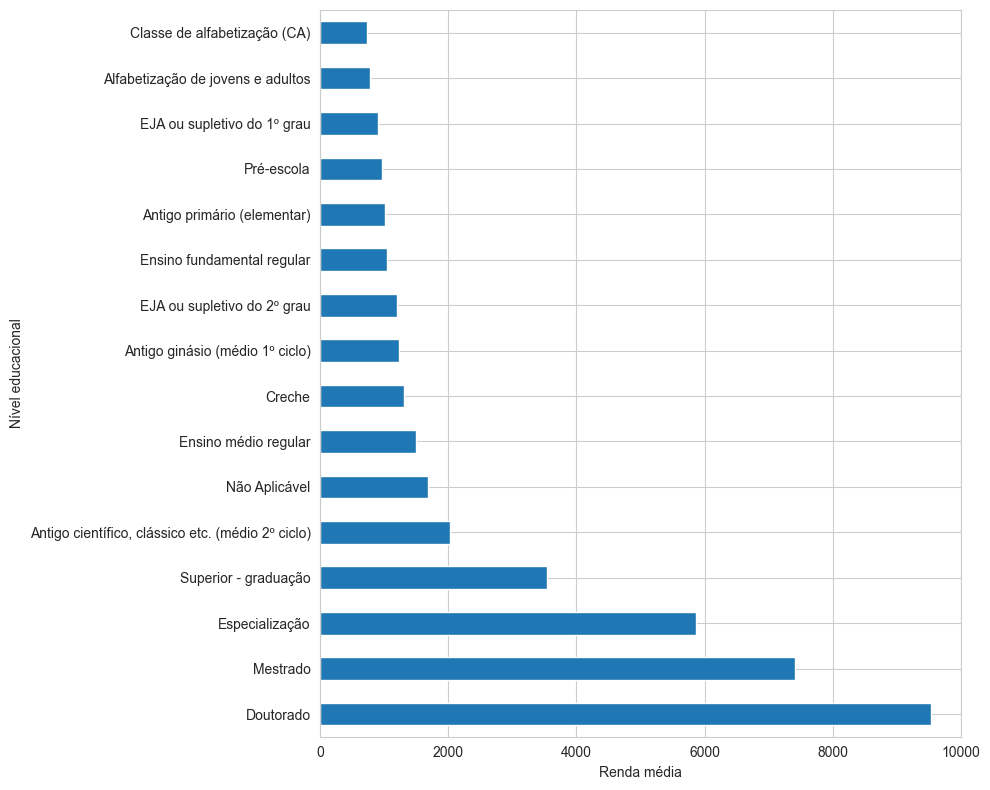

In [129]:
plt.figure(figsize=(10, 8))

(
    df.groupby("nivel_educacional")["renda"]
    .mean()
    .sort_values(ascending=False)
    .plot.barh()
)

plt.xlabel("Renda média")
plt.ylabel("Nível educacional")
plt.tight_layout()
plt.show()

#### Horas trabalhadas por semana

In [130]:
df_trabalhou = df[df["trabalhou"] == "Sim"]

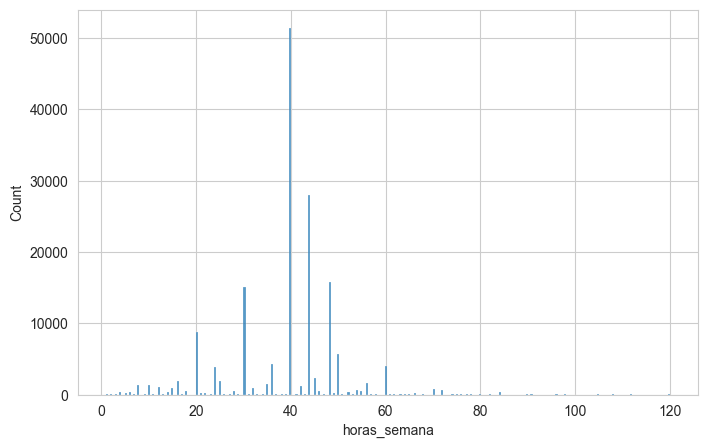

In [131]:
sns.histplot(df_trabalhou["horas_semana"])
plt.show()

In [132]:
df_trabalhou["horas_semana"].describe()

count    162235.000000
mean         38.905273
std          11.735903
min           1.000000
25%          32.000000
50%          40.000000
75%          44.000000
max         120.000000
Name: horas_semana, dtype: float64

#### Relação entre horas trabalhadas e renda

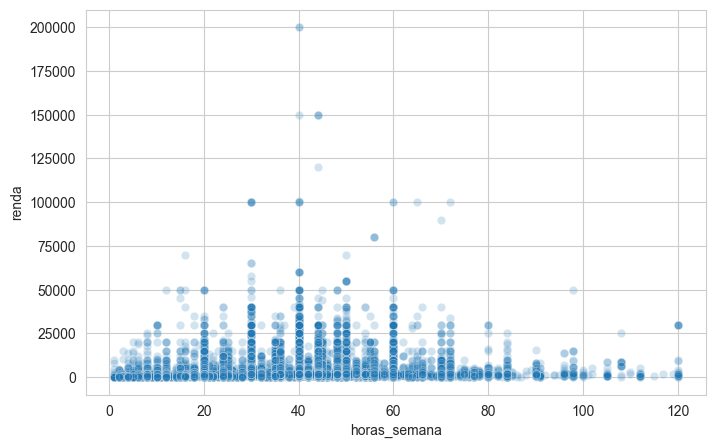

In [133]:
sns.scatterplot(
    data=df_trabalhou,
    x="horas_semana",
    y="renda",
    alpha=0.2
)
plt.show()

#### Carteira assinada

In [134]:
df["carteira_assinada"] = df["carteira_assinada"].map({
    1: "Sim",
    2: "Não",
    999: "Não Aplicável"
})

In [135]:
df["carteira_assinada"].value_counts(dropna=False)

carteira_assinada
Não Aplicável    427849
Sim               54740
Não               48013
Name: count, dtype: int64

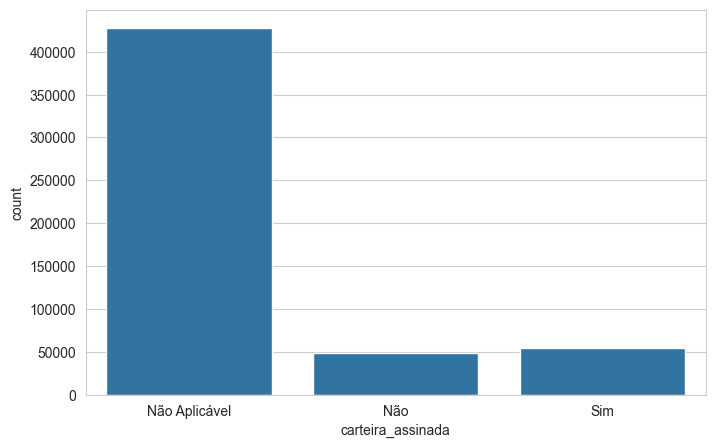

In [136]:
sns.countplot(
    data=df,
    x="carteira_assinada"
)
plt.show()

#### Procurou emprego

In [137]:
df["procurou_emprego"] = df["procurou_emprego"].map({
    1: "Sim",
    2: "Não",
    999: "Não Aplicável"
})

In [138]:
df["procurou_emprego"].value_counts(dropna=False)

procurou_emprego
Não Aplicável    283452
Não              215786
Sim               31364
Name: count, dtype: int64

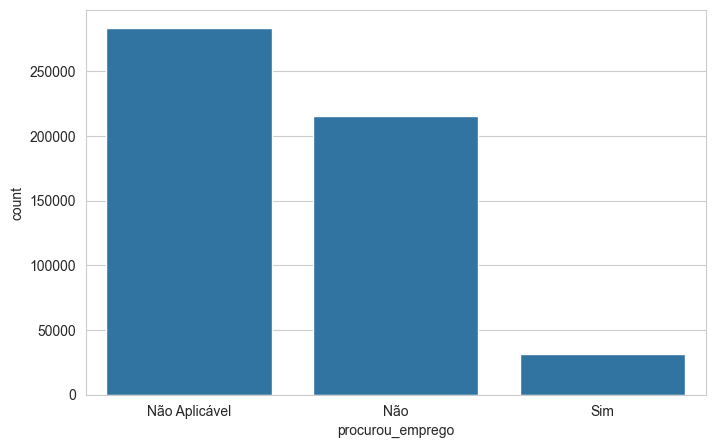

In [139]:
sns.countplot(
    data=df,
    x="procurou_emprego"
)
plt.show()